Report Idea:

Start from Q-learning. Recognize Q-learning cannot solve continuous weight allocation. Proceed to PPO and explain why it can solve continuous weight allocation, but it is built on Q-learning's intuition. How do we pick V(s), how does it connect to neural network (to what we learned), how do we pick the parameters (e.g. how many layers should we pick).

Problems we can face: If you update too aggressively: probabilities explode; policy becomes unstable; performance collapses. In finance terms: The model sees one lucky month → suddenly allocates 90% to Energy forever. Need to restrict learning rate.

Lead us to PPO-clipping to add a hard constraint on policy update size.

Logic should be clearly explained: Reward → Return → Advantage → Objective → Parameter Update: 

We first define a reward function reflecting portfolio performance.
As the agent interacts with the environment, rewards are accumulated into returns.
The critic estimates a baseline value function, allowing computation of the advantage, which measures how much better or worse an action performed relative to expectation.
These advantage estimates enter the PPO surrogate objective, which determines how the policy distribution is adjusted.
The objective is then optimized via gradient ascent to update the parameters of the action distribution.

Talk about we got the idea from this github: https://github.com/tsmatz/reinforcement-learning-tutorials/blob/a8506d6e7f4bf6b3ad200e87dfb5d0ee62dc76d5/04-ppo.ipynb

But clearly the dataset is different: 
1. The CartPole example is:

- 4-dimensional state

- 2 discrete actions

- reward from environment

- episode ends automatically

2. Our project is:

- High-dimensional state (ETF + macro)

- Continuous action (portfolio weights)

- Reward = portfolio return

- No natural “episode end” except sample end

So we must redesign the environment properly.

1. Step 1: Dataset preparation. Besides usual descriptions, state our states: 
At time t, state will include:

- Sector ETF features (momentum, vol, dispersion, etc.)

- Macro features (rates, inflation, etc.)

- Possibly previous weights

Conclusion: Does the RL perform better than some naive baseline model?

In [80]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import warnings
warnings.filterwarnings("ignore")


## Step 1: Load data + clean data + set index

In [81]:
macro_df = pd.read_csv("macro_data.csv")
macro_df["Unnamed: 0"] = pd.to_datetime(macro_df["Unnamed: 0"])
macro_df = macro_df.set_index("Unnamed: 0").sort_index()
macro_df.index.name = "date"
display(macro_df)

,CPI,INDPRO,TERM_SPREAD,FED_RATE,HY_OAS,VIX,CPI_q,INDPRO_q,TERM_SPREAD_m,FED_RATE_m,...,VIX_z,CPI_q_z,INDPRO_q_z,TERM_SPREAD_m_z,FED_RATE_m_z,HY_OAS_m_z,VIX_m_z,curve_inv,high_vol,credit_spread
date,,,,,,,,,,,,,,,,,,,,,
2016-12-31,242.637000,99.0214,1.970000,0.54,4.620000,14.070000,0.006058,0.002792,0.331081,0.317073,...,-0.481474,0.645725,1.189782,2.795910,1.038643,-1.018538,-1.016227,0,0,0
2017-01-31,243.618000,98.7611,1.962516,0.65,4.633392,13.980987,0.007765,0.000000,-0.003799,0.203704,...,-0.498953,0.993252,0.790520,-0.053161,0.489363,0.016223,-0.124984,0,0,0
2017-02-28,244.006000,98.3646,1.970000,0.66,3.950000,11.810000,0.008181,0.000158,0.003814,0.015385,...,-0.960364,1.078891,0.743678,0.013558,-0.349651,-1.582065,-0.655788,0,0,0
2017-03-31,243.892000,99.0137,1.830000,0.79,3.570000,12.540000,0.005172,-0.000078,-0.071066,0.196970,...,-0.770080,0.206501,0.648779,-0.590274,0.420665,-0.950084,0.146048,0,0,0
2017-04-30,244.193000,100.0224,1.821906,0.90,3.559316,12.443833,0.002360,0.012771,-0.004423,0.139241,...,-0.757298,-0.542625,2.218795,-0.087853,0.155158,0.064685,-0.103543,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31,323.364000,101.5867,-0.120000,4.33,3.130000,20.380000,0.008684,0.006153,-0.142857,0.000000,...,0.631240,0.599187,0.623189,-0.311262,0.486852,0.861948,1.075844,1,0,0
2025-09-30,324.368000,101.7779,-0.129730,4.22,2.840000,16.120000,0.008921,0.002950,0.081087,-0.025404,...,-0.432450,0.728875,0.249218,0.267590,-0.900274,-0.899257,-1.324695,1,0,0
2025-10-31,324.330696,101.5163,0.110000,4.09,2.810000,16.290000,0.006825,-0.003707,-1.847912,-0.030806,...,-0.435077,0.028106,-0.630003,-3.314174,-1.109091,-0.023841,-0.072496,0,0,0


In [82]:
etf_df = pd.read_parquet("sector_panel.parquet")  # MultiIndex (date, ticker)
etf_df.head(30)

ret_1m    vol_1m     amihud_1m  avg_corr_1m  xsec_disp_1m
date       ticker                                                             
2016-01-31 BIL     0.000219  0.000225  3.220861e-12     0.750529      0.046963
           VOX     0.012276  0.016287  2.306592e-09     0.750529      0.046963
           XLB    -0.107094  0.017291  4.828052e-11     0.750529      0.046963
           XLE    -0.034980  0.029289  2.081823e-11     0.750529      0.046963
           XLF    -0.088544  0.016266  1.079141e-11     0.750529      0.046963
           XLI    -0.056970  0.014622  1.882635e-11     0.750529      0.046963
           XLK    -0.037124  0.018166  2.528782e-11     0.750529      0.046963
           XLP     0.005348  0.011606  1.625692e-11     0.750529      0.046963
           XLRE   -0.063943  0.014778  7.212851e-07     0.750529      0.046963
           XLU     0.049445  0.010942  1.656133e-11     0.750529      0.046963
           XLV    -0.077190  0.015242  1.347519e-11     0.750529      0.046963
           XLY    -0.051817  0.014947  1.762328e-11     0.750529      0.046963
2016-02-29 BIL     0.000000  0.000201  3.031380e-12     0.572733      0.031915
           VOX     0.039675  0.009659  9.507144e-10     0.572733      0.031915
           XLB     0.078153  0.018255  5.532553e-11     0.572733      0.031915
           XLE    -0.028002  0.020424  1.531520e-11     0.572733      0.031915
           XLF    -0.029005  0.017458  9.986258e-12     0.572733      0.031915
           XLI     0.042609  0.012843  1.637927e-11     0.572733      0.031915
           XLK    -0.006547  0.012570  2.193987e-11     0.572733      0.031915
           XLP     0.003152  0.007772  1.070283e-11     0.572733      0.031915
           XLRE    0.004796  0.018519  1.124784e-06     0.572733      0.031915
           XLU     0.019375  0.010274  1.081675e-11     0.572733      0.031915
           XLV    -0.003611  0.011823  1.386202e-11     0.572733      0.031915
           XLY     0.004453  0.014298  1.754939e-11     0.572733      0.031915
2016-03-31 BIL     0.000000  0.000151  2.866007e-12     0.449260      0.023150
           VOX     0.055728  0.007755  5.110872e-10     0.449260      0.023150
           XLB     0.075731  0.010764  3.899624e-11     0.449260      0.023150
           XLE     0.101659  0.016241  1.271842e-11     0.449260      0.023150
           XLF     0.071591  0.010760  6.835451e-12     0.449260      0.023150
           XLI     0.069735  0.008184  1.167406e-11     0.449260      0.023150

In [83]:
panel = etf_df.join(macro_df, how="left")

# sanity check of joining the two dfs
print(panel.index.get_level_values(0).min(), panel.index.get_level_values(0).max())
print(macro_df.index.min(), macro_df.index.max())

# Check missing macro rows after join
missing = panel[macro_df.columns].isna().any(axis=1).groupby(level=0).any()
print("Missing macro dates:", missing[missing].index)

# restrict to the intersection of dates
common_dates = etf_df.index.get_level_values(0).unique().intersection(macro_df.index)
panel = etf_df.loc[common_dates].join(macro_df, how="left")

# confirm no missing now
missing = panel[macro_df.columns].isna().any(axis=1).groupby(level=0).any()
print("Missing macro dates after restriction:", missing[missing].index)
print("Panel date range:", panel.index.get_level_values(0).min(), panel.index.get_level_values(0).max())

# extract date from multi-index
dates = sorted(panel.index.get_level_values(0).unique())



2016-01-31 00:00:00 2026-01-31 00:00:00
2016-12-31 00:00:00 2025-12-31 00:00:00
Missing macro dates: DatetimeIndex(['2016-01-31', '2016-02-29', '2016-03-31', '2016-04-30',
               '2016-05-31', '2016-06-30', '2016-07-31', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2026-01-31'],
              dtype='datetime64[ms]', name='date', freq=None)
Missing macro dates after restriction: DatetimeIndex([], dtype='datetime64[ms]', name='date', freq=None)
Panel date range: 2016-12-31 00:00:00 2025-12-31 00:00:00


## Step 2: Set up portfolio environment for implementing PPO: define the simulated financial world that the RL agent will interact with  
Each time step represent 1 month.

1. State

At month t (month-end), the agent sees:

- ETF features (ret, vol, illiquidity)

- Cross-sectional regime measures (avg_corr, dispersion)

- Macro features (z-scored CPI, VIX, etc.)

- Previous portfolio weights

2. Action

At each month $t$, the agent chooses portfolio weights:

$$
w_t = (w_{BIL}, w_{VOX}, \dots, w_{XLY})
$$

Constraints:

- Long-only: $w_i \ge 0$
- Fully invested: $\sum_i w_i = 1$
- BIL (cash asset) is included in the allocation universe

3. Reward

After choosing weights at time $t$, the next month’s returns realize.

First compute gross portfolio return:

$$
R^{gross}_{t+1} = w_t^\top R_{t+1}
$$

Turnover is defined as:

$$
\text{turnover}_t = \sum_i |w_{i,t} - w_{i,t-1}|
$$

Transaction cost is parameterized in basis points:

$$
\text{tc} = \frac{\text{tc\_bps}}{10000}
$$

Net return:

$$
R^{net}_{t+1} = R^{gross}_{t+1} - \text{tc} \cdot \text{turnover}_t
$$

Final reward:

$$
r_{t+1}
=
\log\big(1 + R^{net}_{t+1}\big)
-
\gamma \|w_t\|_2^2
$$

Where:

- $\text{tc\_bps}$ controls transaction cost intensity  
- $\gamma$ controls the L2 concentration penalty  

4. Episode

One full training episode consists of:

- Start: December 2016  
- Step forward month-by-month  
- End: December 2022 (for `train_env`)  

Each episode represents one complete historical backtest path.


In [43]:
TICKERS = ["BIL","VOX","XLB","XLE","XLF","XLI","XLK","XLP","XLRE","XLU","XLV","XLY"]

asset_cols  = ["ret_1m","vol_1m","amihud_1m"]
shared_cols = ["avg_corr_1m","xsec_disp_1m"]

# keep macro small + normalized first at this stage, better for neural network training
macro_cols = [
    "CPI_q_z","INDPRO_q_z","TERM_SPREAD_m_z","FED_RATE_m_z","HY_OAS_m_z","VIX_m_z",
    "curve_inv","high_vol","credit_spread"
]

# Set Monthly portfolio environment
# This section is checked by AI
class PortfolioEnv:
    def __init__(self, panel, tickers, asset_cols, shared_cols, macro_cols,
                 tc_bps=10.0, l2_gamma=0.01, start_date=None, end_date=None):
        self.panel = panel
        self.tickers = list(tickers)
        self.asset_cols = list(asset_cols)
        self.shared_cols = list(shared_cols)
        self.macro_cols = list(macro_cols)
        self.l2_gamma = float(l2_gamma)

        # Transaction costs
        self.tc_bps = float(tc_bps)          
        self.tc = self.tc_bps / 10000.0      
        
        all_dates = sorted(panel.index.get_level_values(0).unique())
        if start_date is not None:
            all_dates = [d for d in all_dates if d >= pd.to_datetime(start_date)]
        if end_date is not None:
            all_dates = [d for d in all_dates if d <= pd.to_datetime(end_date)]

        if len(all_dates) < 2:
            raise ValueError("Need at least 2 dates (t and t+1) in the env range.")

        self.dates = all_dates
        self.n_assets = len(self.tickers)

        self.reset()

    def _slice(self, date):
        # enforce consistent ticker ordering
        return self.panel.loc[date].reindex(self.tickers)

    def _get_state(self, date):
        df = self._slice(date)

        asset_block = df[self.asset_cols].to_numpy(np.float32).reshape(-1)  # N*len(asset_cols)
        shared = df[self.shared_cols].iloc[0].to_numpy(np.float32)          # len(shared_cols)
        macro  = df[self.macro_cols].iloc[0].to_numpy(np.float32)           # len(macro_cols)

        # include previous weights to help control turnover
        state = np.concatenate([asset_block, shared, macro, self.w_prev], axis=0).astype(np.float32)
        return state

    def reset(self):
        self.t = 0
        self.done = False
        self.w_prev = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        return self._get_state(self.dates[self.t])

    def step(self, w):
        if self.done:
            raise RuntimeError("Episode is done. Call reset().")

        w = np.asarray(w, dtype=np.float32)
        w = np.clip(w, 0, None)
        w = w / (w.sum() + 1e-12)

        date_tp1 = self.dates[self.t + 1]
        ret_tp1 = self._slice(date_tp1)["ret_1m"].to_numpy(np.float32)

        # Gross portfolio return for month t->t+1
        gross_ret = float(np.dot(w, ret_tp1))

        # Turnover (L1 distance) from previous weights
        turnover = float(np.sum(np.abs(w - self.w_prev)))

        # Transaction cost deducted in return space
        cost = float(self.tc * turnover)
        net_ret = gross_ret - cost

        # Safe log1p (must have 1 + net_ret > 0)
        net_ret = max(net_ret, -0.999999)
        log_ret = float(np.log1p(net_ret))

        # L2 concentration penalty
        l2_pen = float(np.sum(w * w))

        # Reward: net log return minus L2 penalty
        reward = log_ret - self.l2_gamma * l2_pen

        self.w_prev = w
        self.t += 1

        info = {
            "date": date_tp1,
            "gross_ret": gross_ret,
            "net_ret": net_ret,
            "turnover": turnover,
            "cost": cost
        }

        if self.t >= len(self.dates) - 1:
            self.done = True
            return None, reward, True, info

        next_state = self._get_state(self.dates[self.t])
        return next_state, reward, False, info


## Step 3: Train / Val / Test Split

In [44]:
train_env = PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=20.0,
    l2_gamma=0.01,
    start_date="2016-12-31",
    end_date="2022-12-31"
)

val_env = PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=20.0,
    l2_gamma=0.01,
    start_date="2023-01-31",
    end_date="2023-12-31"
)

test_env = PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=20.0,
    l2_gamma=0.01,
    start_date="2024-01-31",
    end_date="2025-12-31"
)
complete_env =  PortfolioEnv(
    panel, TICKERS, asset_cols, shared_cols, macro_cols,
    tc_bps=0,#20.0,
    l2_gamma=0,#0.01,
    start_date="2016-12-31",
    end_date="2025-12-31"
)

# quick check
s0 = train_env.reset()
print("state_dim =", s0.shape[0], "| n_assets =", len(TICKERS))


state_dim = 59 | n_assets = 12


## Step 4: Define PPO Actor–Critic Network (Continuous Weights via Softmax)

- Actor

Input: state

Output: logits (dimension = number of assets)

Apply softmax → weights

- Critic

Input: state

Output: scalar value $V(s)$

We use logits instead of directly outputting weights because neural networks work better in unconstrained space. If we tried to directly output weights, we would need to manually enforce nonnegativity and weights sum to 1, which could make optimization unstable. Instead, network outputs unconstrained real numbers (logits) and apply Softmax to convert these logits into weights, while automatically enforcing constraints during conversion.

The network must be capable of learning:

- Nonlinear regime switching

- Interaction between macro and sector signals

- Nonlinear dependence between dispersion & allocation

- Risk-off vs risk-on shifts

We believe 2 layer is a balance between flexibility and stability, given our relatively small observation size to reduce overfitting. Research show ReLU usually performs better for small MLPs, so we pick ReLU as our activation function.

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state_dim = s0.shape[0]
n_assets = len(TICKERS)

# Checked by AI
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state_dim = s0.shape[0]
n_assets  = len(TICKERS)

class ActorCritic(nn.Module):
    """
    Combined network:
      - shared trunk
      - actor head outputs logits (-> Dirichlet via your _dirichlet_from_logits)
      - critic head outputs scalar V(s)
    """
    def __init__(self, state_dim, n_assets, hidden=128):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.actor_head  = nn.Linear(hidden, n_assets)  # logits
        self.critic_head = nn.Linear(hidden, 1)         # V(s)

    def forward(self, x):
        z = self.shared(x)
        logits = self.actor_head(z)                     # (batch, n_assets) or (n_assets,)
        value  = self.critic_head(z).squeeze(-1)        # (batch,) or scalar
        weights = F.softmax(logits, dim=-1)             # could be useful for inspection/debug
        return weights, logits, value


ac = ActorCritic(state_dim, n_assets, hidden=128).to(device)

optimizer = torch.optim.Adam(ac.parameters(), lr=3e-4)

## Step 5: Define PPO Hyperparameters

In [46]:
gamma = 0.99                # discount rate, determines how much the agent cares about future rewards
clip_eps = 0.2              # PPO clipping
value_coef = 0.5            # coefficient on the value loss term, common default = 0
entropy_coef = 0.01         # add a small entropy_coef to encourage a bit more exploration
ppo_epochs = 10             
batch_size = 64             # same idea as lecture notes, split rollout into mini-batches, and compute gradient on chunks of size 64

## Step 6: Rollout Function

**Goal:** Generate experience tuples  
$$
(s_t, a_t, r_{t+1})
$$  
for each month in the training period.

At each month $t$:

1. **State $s_t$**
   - Sector ETF features (asset-level)
   - Cross-sectional regime features (correlation, dispersion)
   - Macro features
   - Previous portfolio weights

2. **Actor produces logits**
   - Logits are unconstrained real numbers.

3. **Convert logits into portfolio weights**
   - We use a Dirichlet distribution.
   - Sampled weights are:
     - Long-only
     - Sum to 1

4. **Take action**
   - Sample weights $w_t$
   - Pass into `env.step(w_t)`

5. **Environment computes reward**
   $$
   r_{t+1}
   =
   \log(1 + w_t^\top R_{t+1})
   - \text{tc} \cdot \text{turnover}
   - \gamma \|w_t\|_2^2
   $$

6. **Store for training**
   - States $s_t$
   - Actions $w_t$
   - Rewards $r_{t+1}$
   - Log probability of action under current policy
   - Critic value estimate $V(s_t)$

So Step 6 = run one historical backtest path and record everything.

In [47]:
def _dirichlet_from_logits(logits, min_conc=1e-3):
    # logits: (..., n_assets)
    # concentrations must be > 0
    alpha = F.softplus(logits) + min_conc
    return torch.distributions.Dirichlet(alpha), alpha

@torch.no_grad()
def collect_rollout(env, max_steps=None):
    states, actions, logps, rewards, dones, values, entropies = [], [], [], [], [], [], []
    infos = []

    s = env.reset()
    done = False
    steps = 0

    while not done:
        s_t = torch.tensor(s, dtype=torch.float32, device=device)
        
        weights, logits, v = ac(s_t)
        dist, alpha = _dirichlet_from_logits(logits)

        a = dist.sample()
        logp = dist.log_prob(a)
        ent = dist.entropy()

        
        a_np = a.detach().cpu().numpy().astype(np.float32)
        s2, r, done, info = env.step(a_np)

        states.append(s)
        actions.append(a_np)
        logps.append(float(logp.cpu().item()))
        rewards.append(float(r))
        dones.append(done)
        values.append(float(v.cpu().item()))
        entropies.append(float(ent.cpu().item()))
        infos.append(info)

        s = s2 if s2 is not None else s
        steps += 1
        if max_steps is not None and steps >= max_steps:
            break

    return {
        "states": np.array(states, dtype=np.float32),
        "actions": np.array(actions, dtype=np.float32),
        "logps": np.array(logps, dtype=np.float32),
        "rewards": np.array(rewards, dtype=np.float32),
        "values": np.array(values, dtype=np.float32),
        "entropies": np.array(entropies, dtype=np.float32),
        "infos": infos,  
    }


## Step 7: Returns + advantages

We now compute learning targets.

### Return

Cumulative discounted return:

$$
G_t
=
r_{t+1}
+
\gamma r_{t+2}
+
\gamma^2 r_{t+3}
+
\dots
$$

This is the total future reward from time $t$ onward.


### Advantage

Advantage measures how good the action was relative to expectation:

$$
A_t
=
G_t - V(s_t)
$$

- If $A_t > 0$: action performed better than expected  
- If $A_t < 0$: worse than expected  

Advantage is the key learning signal for the actor.


In [48]:
def compute_returns_advantages(rewards, values, gamma):
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    G = 0.0
    for t in reversed(range(T)):
        G = rewards[t] + gamma * G
        returns[t] = G
    adv = returns - values
    return returns, adv


## Step 8: PPO-Clip update step

This is where learning happens.

### 8.1 Compute Probability Ratio

We compare new policy vs old policy:

$$
r_t(\theta)
=
\frac{\pi_{\text{new}}(a_t | s_t)}
     {\pi_{\text{old}}(a_t | s_t)}
=
\exp(\log \pi_{\text{new}} - \log \pi_{\text{old}})
$$

This ratio measures how much the policy changed.

### 8.2 PPO Clipped Objective

PPO limits how aggressively the policy can change:

$$
\min
\left(
r_t A_t,
\;
\text{clip}(r_t, 1-\epsilon, 1+\epsilon) A_t
\right)
$$

- If the update is too large, it is clipped.
- Ensures stable learning.

### 8.3 Critic Update

Critic minimizes squared error:

$$
L_V
=
\left(V(s_t) - G_t\right)^2
$$


### 8.4 Entropy Bonus

Encourages exploration:

- Higher entropy = more diversified allocations
- Prevents premature collapse into one asset


### 8.5 Total PPO Loss

Overall objective minimized:

$$
L
=
L_{\text{policy}}
+
c_v L_V
-
c_e \cdot \text{Entropy}
$$

Then we take a gradient step.

So Step 8 = update actor and critic using PPO-Clip.


In [49]:
def ppo_update(rollout):
    states = torch.tensor(rollout["states"], dtype=torch.float32, device=device)
    actions = torch.tensor(rollout["actions"], dtype=torch.float32, device=device)
    old_logps = torch.tensor(rollout["logps"], dtype=torch.float32, device=device)

    returns_np, adv_np = compute_returns_advantages(
        rollout["rewards"], rollout["values"], gamma
    )
    returns = torch.tensor(returns_np, dtype=torch.float32, device=device)
    adv = torch.tensor(adv_np, dtype=torch.float32, device=device)

    # normalize advantage
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)

    N = states.shape[0]
    idx = np.arange(N)

    for _ in range(ppo_epochs):
        np.random.shuffle(idx)
        for start in range(0, N, batch_size):
            mb = idx[start:start + batch_size]

            s_mb = states[mb]
            a_mb = actions[mb]
            old_logp_mb = old_logps[mb]
            ret_mb = returns[mb]
            adv_mb = adv[mb]

            # current policy distribution (combined ActorCritic)
            w_mean, logits, v = ac(s_mb)
            dist, alpha = _dirichlet_from_logits(logits)

            logp = dist.log_prob(a_mb)
            entropy = dist.entropy().mean()

            ratio = torch.exp(logp - old_logp_mb)

            # clipped surrogate objective
            surr1 = ratio * adv_mb
            surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_mb
            policy_loss = -torch.min(surr1, surr2).mean()

            # critic loss (v comes from ac)
            value_loss = F.mse_loss(v, ret_mb)

            loss = policy_loss + value_coef * value_loss - entropy_coef * entropy

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(ac.parameters(), 1.0)

            optimizer.step()


## Step 9: Training loop (+ quick validation)

Repeat:

1. Collect rollout on `train_env`
2. Update policy using PPO
3. Evaluate on `val_env` (no training)

Validation is used to:
- Monitor overfitting
- Tune hyperparameters

In [50]:
n_iters = 300
train_ep_rewards = []
val_ep_rewards = []

for it in range(1, n_iters + 1):
    roll = collect_rollout(train_env)
    train_ep_rewards.append(float(roll["rewards"].sum()))

    ppo_update(roll)

    vroll = collect_rollout(val_env)
    val_ep_rewards.append(float(vroll["rewards"].sum()))

    if it % 20 == 0:
        print(
            f"iter {it:4d} | "
            f"train_ep_reward {train_ep_rewards[-1]:.4f} | "
            f"val_ep_reward {val_ep_rewards[-1]:.4f}"
        )


iter   20 | train_ep_reward 0.2004 | val_ep_reward 0.0882
iter   40 | train_ep_reward 0.4046 | val_ep_reward 0.0792
iter   60 | train_ep_reward 0.3658 | val_ep_reward -0.0055
iter   80 | train_ep_reward 0.3485 | val_ep_reward 0.1097
iter  100 | train_ep_reward 0.2831 | val_ep_reward 0.0507
iter  120 | train_ep_reward 0.3277 | val_ep_reward 0.0108
iter  140 | train_ep_reward 0.4200 | val_ep_reward -0.0001
iter  160 | train_ep_reward 0.4202 | val_ep_reward 0.0404
iter  180 | train_ep_reward 0.2497 | val_ep_reward 0.0458
iter  200 | train_ep_reward 0.4607 | val_ep_reward 0.0303
iter  220 | train_ep_reward 0.3207 | val_ep_reward 0.0689
iter  240 | train_ep_reward 0.3036 | val_ep_reward 0.0595
iter  260 | train_ep_reward 0.1783 | val_ep_reward 0.0745
iter  280 | train_ep_reward 0.3731 | val_ep_reward 0.0132
iter  300 | train_ep_reward 0.3679 | val_ep_reward 0.0480


**Caveat**:
does the following plot training vs. validation rewards make sense?

**Look at Return instead of reward**

**Look at reward at each time step**

## Step 10: Plot Training vs Validation Rewards

check whether learning is happening

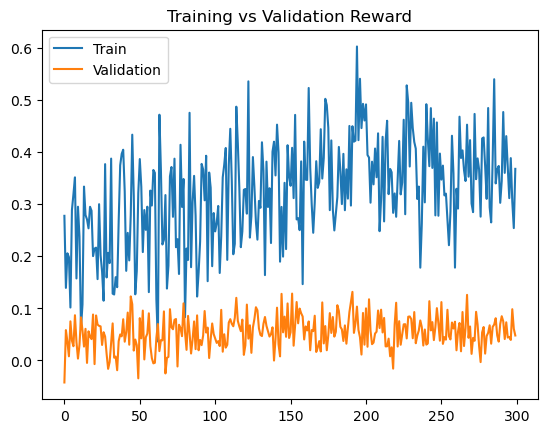

In [51]:
plt.plot(train_ep_rewards, label="Train")
plt.plot(val_ep_rewards, label="Validation")
plt.legend()
plt.title("Training vs Validation Reward")
plt.show()

Train reward trending upward

Validation reward not collapsing

There is divergence between train and val, recall our split:

Train: 2016–2022

Val: 2023

Test: 2024–2025

Markets in 2023 were structurally different from 2016–2021 (rate hikes, regime shift, dispersion changes, etc.). Such gap suggests generalization is limited and mild overfitting.

How to fix? Tune hyperparameters?

## Step 11: Test Set Evaluation and Backtest Construction

Freezing the trained model

Running rollout on test_env

Converting it into return series

Plotting cumulative return

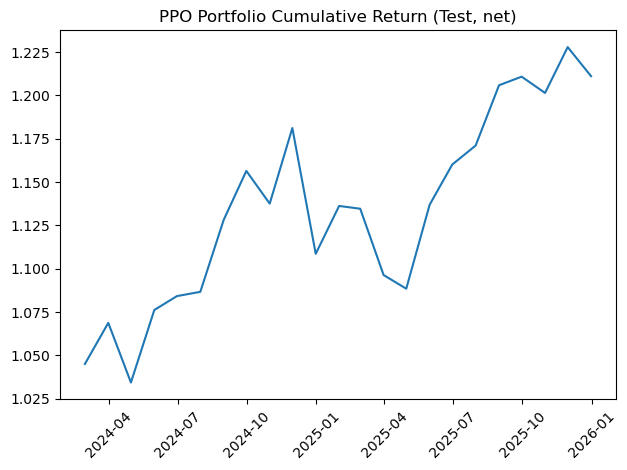

In [52]:
test_roll = collect_rollout(test_env)

test_infos = test_roll["infos"]
net_rets = np.array([info["net_ret"] for info in test_infos], dtype=float)
dates = [info["date"] for info in test_infos]

cum_ret = np.cumprod(1 + net_rets)

import matplotlib.pyplot as plt
plt.plot(dates, cum_ret)
plt.title("PPO Portfolio Cumulative Return (Test, net)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 12: Convert Test Rollout Into Backtest Series

In [53]:
@torch.no_grad()
def run_policy_through_env_dirichlet(env, model, device, deterministic=True):
    """
    NEW version for your Dirichlet + softmax-logits ActorCritic.

    Records:
      - date
      - net_ret (from info)
      - reward (env reward)
      - wealth curve
      - weights used (action)
      - critic value V(s)
      - optional: latent representation z from shared trunk
      - optional: entropy of Dirichlet
    """
    s = env.reset()
    done = False

    dates, net_rets, rewards, values, entropies = [], [], [], [], []
    W = []
    Z = []

    while not done:
        s_t = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)

        # forward pass
        w_mean, logits, v = model(s_t)   # w_mean = softmax(logits)
        logits = logits.squeeze(0)
        v = v.squeeze(0)

        # latent trunk representation (useful for regime analysis of "agent state")
        z = model.shared(s_t).squeeze(0).detach().cpu().numpy()
        Z.append(z)

        # policy distribution
        dist, alpha = _dirichlet_from_logits(logits)

        if deterministic:
            a = w_mean.squeeze(0)              # deterministic "mean" action
            ent = dist.entropy()               # still defined
        else:
            a = dist.sample()                  # stochastic action
            ent = dist.entropy()

        a_np = a.detach().cpu().numpy().astype(np.float32)

        s2, r, done, info = env.step(a_np)

        dates.append(pd.to_datetime(info["date"]))
        net_rets.append(float(info["net_ret"]))
        rewards.append(float(r))
        values.append(float(v.cpu().item()))
        entropies.append(float(ent.cpu().item()))
        W.append(a_np.astype(float))

        if s2 is None:
            break
        s = s2

    W = np.vstack(W) if len(W) else np.zeros((0, len(env.tickers)))
    out = pd.DataFrame(W, columns=[f"w_{tkr}" for tkr in env.tickers])
    out["net_ret"] = np.array(net_rets, dtype=float)
    out["reward"]  = np.array(rewards, dtype=float)
    out["value"]   = np.array(values, dtype=float)
    out["entropy"] = np.array(entropies, dtype=float)
    out["wealth"]  = np.cumprod(1.0 + out["net_ret"].to_numpy())
    out["date"]    = dates

    # expand Z into columns z0, z1, ...
    if len(Z) > 0:
        Zm = np.vstack(Z)
        for j in range(Zm.shape[1]):
            out[f"z{j}"] = Zm[:, j]

    return out


## Step 13: Compute financial metrics for comparison (Sharpe Ratio, Max drawdown, Volatility...) 

In [54]:
def get_performance_metrics(returns, periods=12, rf=0):
    returns = np.asarray(returns)
    wealth = np.cumprod(1+returns)

    end_return = wealth[-1] - 1
    years = len(returns)/periods

    cagr = np.nan
    if years > 0:
        cagr = (wealth[-1] ** (1/years))-1
    
    peak = np.maximum.accumulate(wealth)
    max_drawdown = float(((wealth/peak) -1).min())

    annualized_vol = np.std(returns, ddof=1) * np.sqrt(periods)
    #highest vol regime observed
    vol = pd.Series(returns).rolling(6).std() * np.sqrt(12)
    max_rolling_vol = vol.max()

    sharpe = np.mean(returns)*(periods)/annualized_vol

    return wealth[-1], cagr, max_drawdown, annualized_vol, max_rolling_vol,sharpe

In [89]:
def mc_test_policy_dirichlet(env, model, device, num_sims=200, seed=123):
    runs = []
    for i in range(num_sims):
        seed = seed + i
        np.random.seed(seed)
        torch.manual_seed(seed)

        out = run_policy_through_env_dirichlet(env, model, device=device, deterministic=False)
        returns = out["net_ret"].to_numpy()

        end_wealth, cagr, mdd, ann_vol, rol_vol, sharpe = get_performance_metrics(returns, periods=12, rf=0)

        runs.append({
            "seed": seed,
            "simulation": i+1,
            "end_wealth": float(end_wealth),
            "cagr": float(cagr),
            "max_drawdown": float(mdd),
            "annualized_vol": float(ann_vol),
            "max_vol_rolling_6m": float(rol_vol),
            "sharpe": float(sharpe),
        })
    return pd.DataFrame(runs)

In [98]:
def plot_metrics(mc_df, title="V0 Agent Perfomance Distribution v/s Benchmark Dashboard"):
    fig = plt.figure(figsize=(16,12))
    cols = mc_df.drop(columns=["simulation","seed"]).columns.to_list()
    benchmark = {
        "end_wealth": 1.2054414169691656,
        "cagr": 0.09792596151524058,
        "max_drawdown": -0.23166865769509815,
        "annualized_vol": 0.27278683845913476,
        "max_vol_rolling_6m": 0.5389250237567842,
        "sharpe": 0.47729462181507226
    }

    for i, col in enumerate(cols):
        ax = fig.add_subplot(3,3,i+1)
        ax.hist(mc_df[col].dropna(), bins=40)
        ax.set_title(f"{col} distribution")

        ax.axvline(
                benchmark[col],
                color="red",
                linestyle="--",
                linewidth=2,
                label="Benchmark"
            )
        ax.legend()


    ax6 = fig.add_subplot(3,3,7)
    ax6.scatter(mc_df["annualized_vol"], mc_df["cagr"], alpha=0.5)
    ax6.set_title("Vol vs CAGR")
    ax6.set_xlabel("Annualized Volatility")
    ax6.set_ylabel("CAGR")
    ax6.scatter(
        benchmark["annualized_vol"],
        benchmark["cagr"],
        color="red",
        s=120,
        zorder=5,
        label="Benchmark"
    )
    ax6.legend()

    ax7 = fig.add_subplot(3,3,8)
    ax7.scatter(mc_df["max_drawdown"], mc_df["cagr"], alpha=0.5)
    ax7.set_title("Max Drawdown vs CAGR")
    ax7.set_xlabel("Max Drawdown")
    ax7.set_ylabel("CAGR")
    ax7.scatter(
        benchmark["max_drawdown"],
        benchmark["cagr"],
        color="red",
        s=120,
        zorder=5,
        label="Benchmark"
    )
    ax7.legend()

    ax8 = fig.add_subplot(3,3,9)
    ax8.scatter(mc_df["max_vol_rolling_6m"], mc_df["cagr"], alpha=0.5)
    ax8.set_title("Max Vol (6m Rolling) vs CAGR")
    ax8.set_xlabel("Max Vol Rolling 6m")
    ax8.set_ylabel("CAGR")

    ax8.scatter(
        benchmark["max_vol_rolling_6m"],
        benchmark["cagr"],
        color="red",
        s=120,
        zorder=5,
        label="Benchmark"
    )
    ax8.legend()
    
    fig.suptitle(title, fontsize=20)
    fig.tight_layout()
    plt.show()


#got this code from chatgpt:
def plot_representative_paths(env, model, device, mc_df, base_seed=12345):
    # pick representative sims by CAGR
    best_i = int(mc_df["cagr"].idxmax())
    worst_i = int(mc_df["cagr"].idxmin())
    med_target = mc_df["cagr"].median()
    median_i = int((mc_df["cagr"] - med_target).abs().idxmin())

    picks = [("Best", best_i), ("Median", median_i), ("Worst", worst_i)]

    plt.figure(figsize=(12,5))
    for label, idx in picks:
        seed = int(mc_df.loc[idx, "seed"])
        np.random.seed(seed); torch.manual_seed(seed)
        out = run_policy_through_env_dirichlet(env, model, device=device, deterministic=False)
        plt.plot(out["date"], out["wealth"], label=f"{label} (seed={seed})")

    plt.title("Representative MC Wealth Paths")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [91]:
mc_df = mc_test_policy_dirichlet(test_env, ac, device=device, num_sims=1000)
mc_df.iloc[:, 2:].describe(percentiles=[0.05, 0.5, 0.95])

,end_wealth,cagr,max_drawdown,annualized_vol,max_vol_rolling_6m,sharpe
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1.251017,0.123763,-0.070382,0.092859,0.135102,1.311092
std,0.045403,0.021279,0.016861,0.006141,0.012645,0.222069
min,1.095286,0.048632,-0.144047,0.073306,0.102062,0.510451
5%,1.178486,0.089464,-0.100581,0.082966,0.113752,0.962635
50%,1.249915,0.123431,-0.069043,0.092834,0.134934,1.304156
95%,1.324969,0.158136,-0.045047,0.102969,0.156738,1.675602
max,1.397593,0.190833,-0.034506,0.111952,0.174576,2.016205


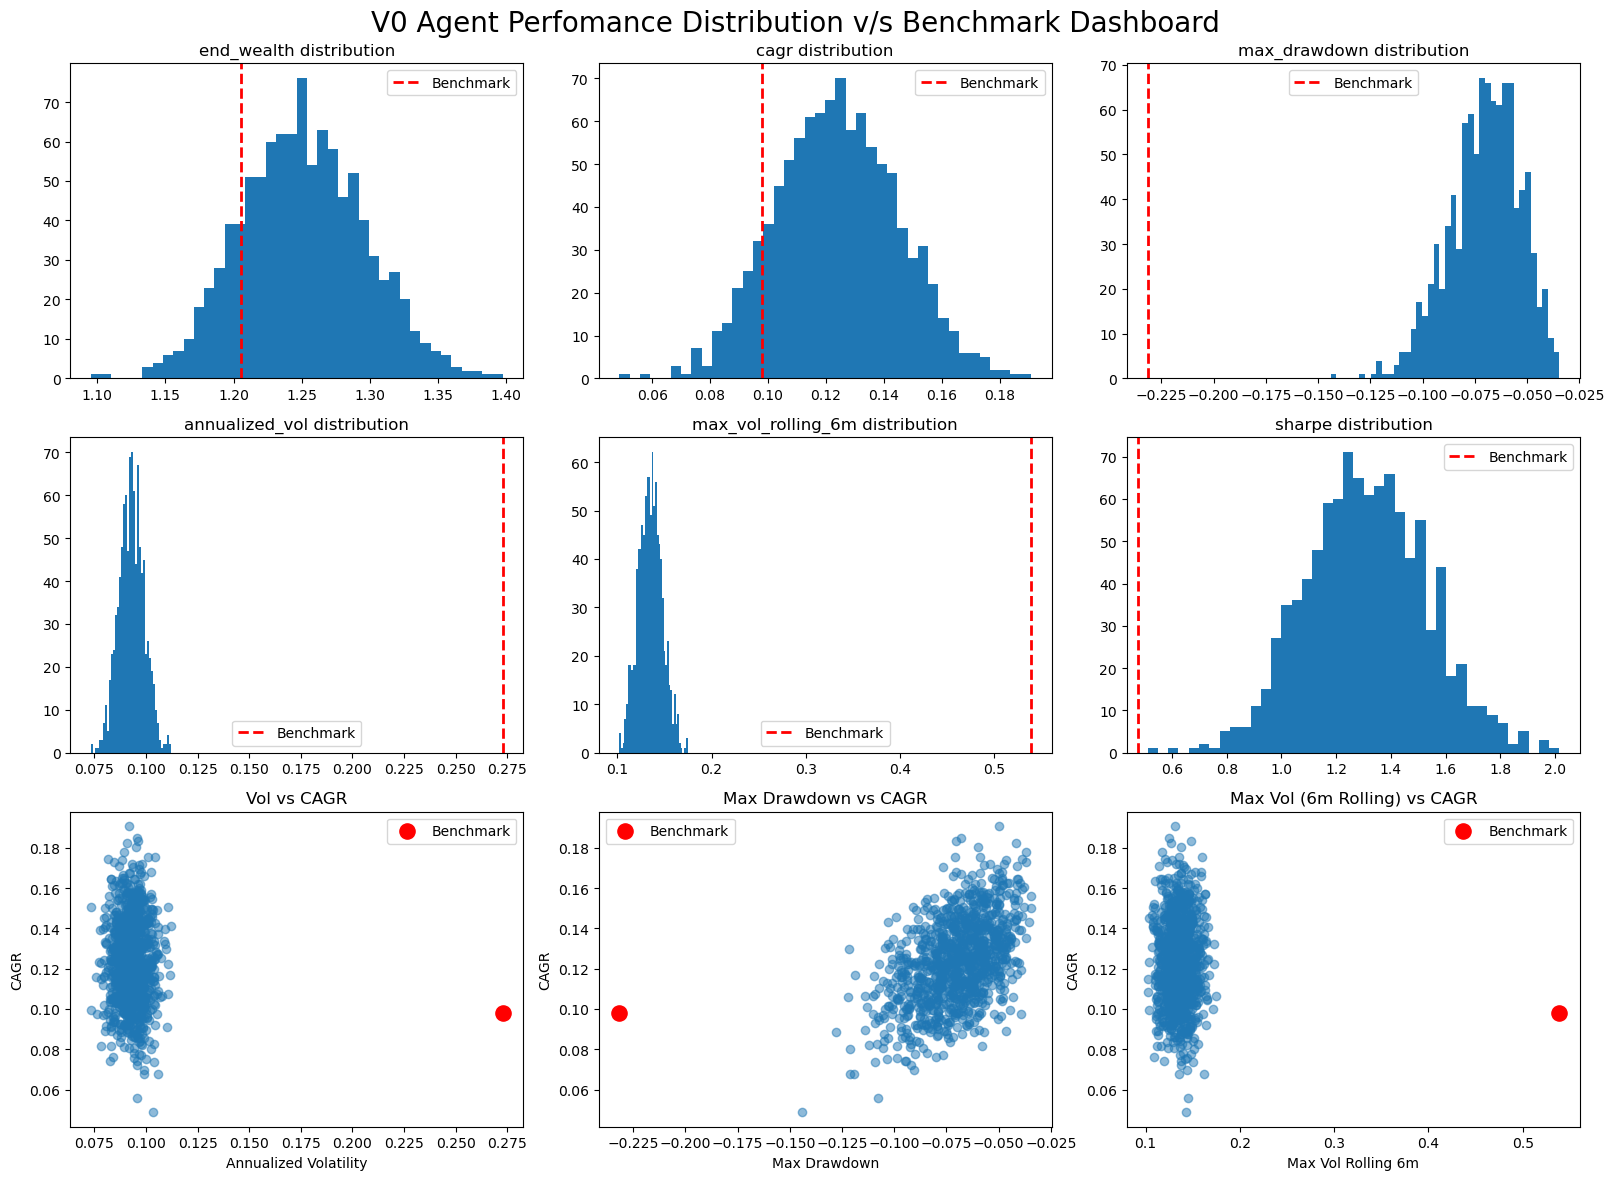

In [99]:
plot_metrics(mc_df)

## Step 14: Compare Against Benchmark （Run Sequential Markowitz model over same test window）

## Step 15: Inspect Learned Behavior

For instance:

Does PPO allocate more to BIL during high VIX?

Does it rotate sectors during high dispersion?

Does it reduce risk during curve inversion?

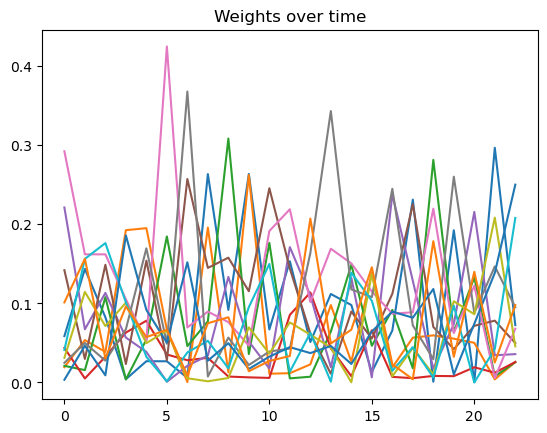

In [59]:
weights = np.array(test_roll["actions"])
plt.plot(weights)
plt.title("Weights over time")
plt.show()

### Regime analysis

In [84]:
#separating asset level info from date level info and transforming asset level to date level. 
asset_cols = ['ret_1m', 'vol_1m']
date_cols = ['avg_corr_1m', 'xsec_disp_1m', 'CPI_q_z', 'INDPRO_q_z', 'TERM_SPREAD_m_z', 'FED_RATE_m_z',
       'HY_OAS_m_z', 'VIX_m_z', 'curve_inv', 'high_vol', 'credit_spread']

asset_mean = panel[asset_cols].groupby(level=0).mean().add_suffix("_mean")
print(f"asset mean shape : {asset_mean.shape}")
asset_std = panel[asset_cols].groupby(level=0).std().add_suffix("_std")
print(f"asset std shape : {asset_std.shape}")
date_level = panel[date_cols].groupby(level=0).first()
print(f"date level shape : {date_level.shape}")

df = pd.concat([asset_mean, asset_std, date_level], axis=1).dropna()
print(df.shape)

train_mask = (df.index <= "2022-12-31")

scaler = StandardScaler().fit(df.loc[train_mask].values)
df_scaled = scaler.transform(df)

K = 4
hmm = GaussianHMM(n_components=K, covariance_type="diag", n_iter=500, random_state=0)
hmm.fit(df_scaled[train_mask])

mkt_regime = pd.Series(hmm.predict(df_scaled), index=df.index, name="mkt_regime")
summary = df.join(mkt_regime).groupby("mkt_regime").mean()
summary

asset mean shape : (109, 2)
asset std shape : (109, 2)
date level shape : (109, 11)
(109, 15)


,ret_1m_mean,vol_1m_mean,ret_1m_std,vol_1m_std,avg_corr_1m,xsec_disp_1m,CPI_q_z,INDPRO_q_z,TERM_SPREAD_m_z,FED_RATE_m_z,HY_OAS_m_z,VIX_m_z,curve_inv,high_vol,credit_spread
mkt_regime,,,,,,,,,,,,,,,
0,-0.002160,0.012314,0.038800,0.005112,0.593799,0.036816,-0.692508,-0.505008,0.056804,-0.261855,0.117481,0.016198,0.592593,0.000000,0.111111
1,0.007285,0.015628,0.041835,0.006118,0.487746,0.041098,-0.437432,-0.056787,0.139420,-0.855034,0.466706,0.242893,0.846154,0.615385,0.076923
2,0.015926,0.006887,0.024435,0.002795,0.346084,0.024556,-0.087704,0.144979,-0.373375,-0.509202,-0.102882,-0.226378,0.324324,0.000000,0.189189
3,0.013437,0.011294,0.037436,0.005119,0.504663,0.037394,0.654352,0.183194,-0.032382,0.211762,-0.039064,0.095112,0.000000,0.343750,0.062500


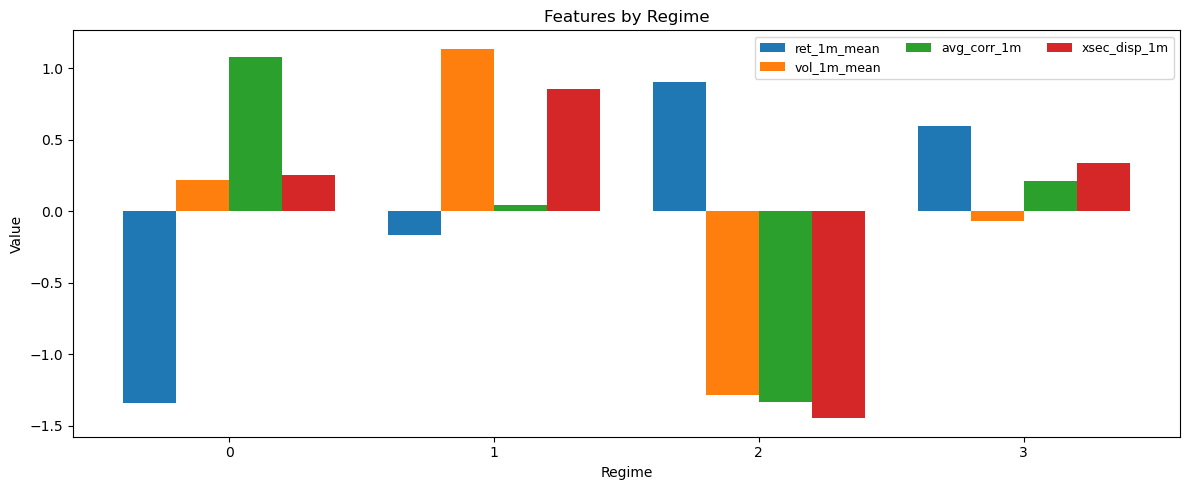

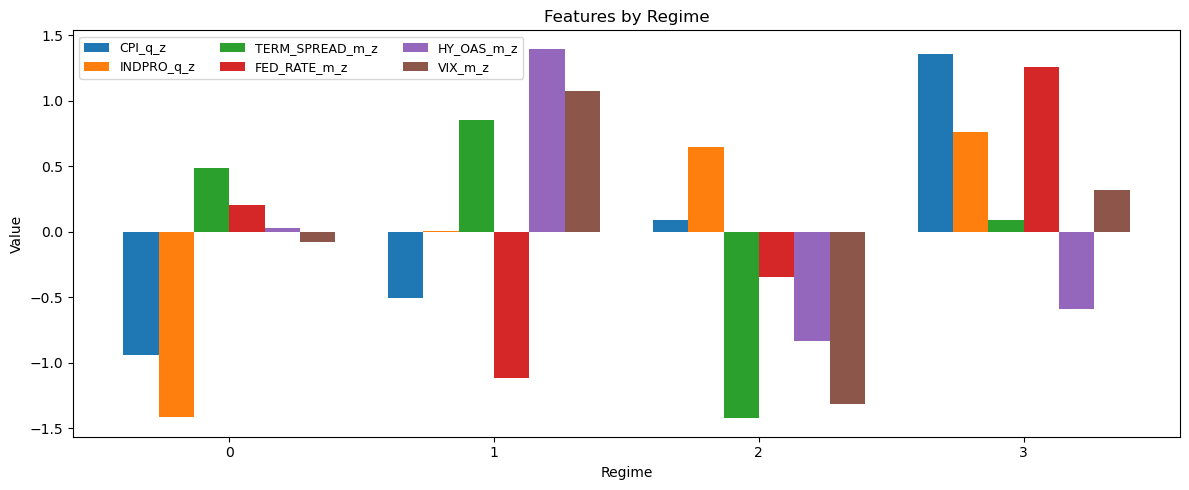

In [85]:


visuals = [
    ['ret_1m_mean', 'vol_1m_mean', 'avg_corr_1m', 'xsec_disp_1m'],
    ['CPI_q_z', 'INDPRO_q_z', 'TERM_SPREAD_m_z', 'FED_RATE_m_z', 'HY_OAS_m_z', 'VIX_m_z']
    
]
summary = (summary-summary.mean())/summary.std()
for cols in visuals:
    regimes = summary.index
    n_regimes = len(regimes)
    n_vars = len(cols)

    x = np.arange(n_regimes)

    # choose width based on how many bars you have
    width = 0.8 / n_vars   # total group width ~0.8

    plt.figure(figsize=(12,5))

    for i, col in enumerate(cols):
        plt.bar(x + i*width, summary[col].values, width=width, label=col)

    # center tick labels under the group
    plt.xticks(x + width*(n_vars-1)/2, regimes)

    plt.xlabel("Regime")
    plt.ylabel("Value")
    plt.title("Features by Regime")
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


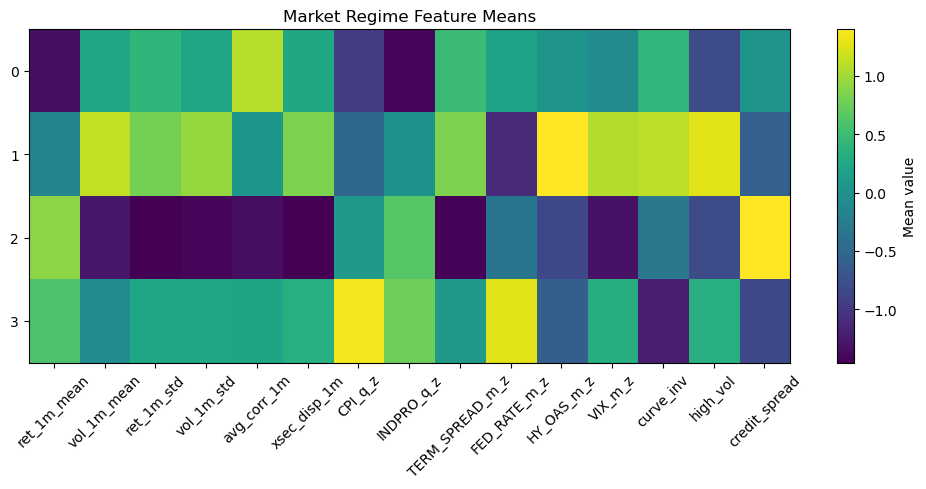

In [62]:
cols = summary.columns.to_list()
data = summary

plt.figure(figsize=(10,5))
plt.imshow(data.values, aspect="auto")
plt.colorbar(label="Mean value")

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(data.index)), data.index)

plt.title("Market Regime Feature Means")
plt.tight_layout()
plt.show()

### Analyzing performance per regime

In [63]:
n_sims = 1000
base_seed = 123

runs = []

for i in range(n_sims):
    seed = base_seed + i
    np.random.seed(seed)
    torch.manual_seed(seed)

    out = run_policy_through_env_dirichlet(complete_env, ac, device=device, deterministic=False)

    # index by date
    out["date"] = pd.to_datetime(out["date"])
    out = out.set_index("date")

    # keep only what you want to average
    runs.append(out)

# stack all sims then average by date
mc_all = pd.concat(runs)                      # index = date (repeats 1000 times)
out = mc_all.groupby(level=0).mean()     # one row per date

out.head()



,w_BIL,w_VOX,w_XLB,w_XLE,w_XLF,w_XLI,w_XLK,w_XLP,w_XLRE,w_XLU,...,z118,z119,z120,z121,z122,z123,z124,z125,z126,z127
date,,,,,,,,,,,,,,,,,,,,,
2017-01-31,0.092242,0.092000,0.049032,0.054619,0.084900,0.060319,0.157533,0.125399,0.031151,0.042654,...,0.441201,0.529362,0.213061,0.000000,0.000000e+00,1.643594,0.0,0.0,0.646239,0.0
2017-02-28,0.086585,0.081607,0.065815,0.062993,0.075672,0.075038,0.151237,0.134686,0.042171,0.037109,...,0.470400,0.000596,0.181416,0.104461,0.000000e+00,1.022218,0.0,0.0,0.564627,0.0
2017-03-31,0.080170,0.080539,0.059577,0.063291,0.076394,0.067638,0.177455,0.119723,0.040133,0.044168,...,0.637399,0.126761,0.219602,0.118885,0.000000e+00,1.038693,0.0,0.0,0.537293,0.0
2017-04-30,0.082007,0.078340,0.061379,0.061623,0.070083,0.083673,0.167139,0.116367,0.039864,0.043645,...,0.645875,0.000000,0.232425,0.289472,0.000000e+00,1.051032,0.0,0.0,0.655841,0.0
2017-05-31,0.070659,0.072507,0.058345,0.062236,0.076919,0.093985,0.173971,0.128641,0.037875,0.037670,...,0.906717,0.000000,0.159045,0.242981,1.760889e-07,1.213633,0.0,0.0,0.809431,0.0


In [64]:
regime_cols = df[["ret_1m_mean","curve_inv","VIX_m_z","HY_OAS_m_z","credit_spread","CPI_q_z"]]
out_regime = out[['net_ret', 'reward', 'wealth']]
regime_perf_df = out.join(mkt_regime, how="left")
regime_perf_df = regime_perf_df.join(regime_cols, how="left")
cols = ['net_ret', 'reward', 'wealth',
        'mkt_regime', 'ret_1m_mean', 'curve_inv', 'VIX_m_z',
       'HY_OAS_m_z', 'credit_spread', 'CPI_q_z']
regime_perf_df = regime_perf_df[cols]
regime_perf_df.head()

,net_ret,reward,wealth,mkt_regime,ret_1m_mean,curve_inv,VIX_m_z,HY_OAS_m_z,credit_spread,CPI_q_z
date,,,,,,,,,,
2017-01-31,0.017108,0.016953,1.017108,2,0.013975,0,-0.124984,0.016223,0,0.993252
2017-02-28,0.029621,0.029162,1.047235,2,0.026933,0,-0.655788,-1.582065,0,1.078891
2017-03-31,-0.000661,-0.000670,1.046544,2,-0.003701,0,0.146048,-0.950084,0,0.206501
2017-04-30,0.010535,0.010474,1.057571,2,0.008050,0,-0.103543,0.064685,0,-0.542625
2017-05-31,0.010144,0.010077,1.068298,2,0.006076,0,-0.770055,0.709060,0,-1.112679


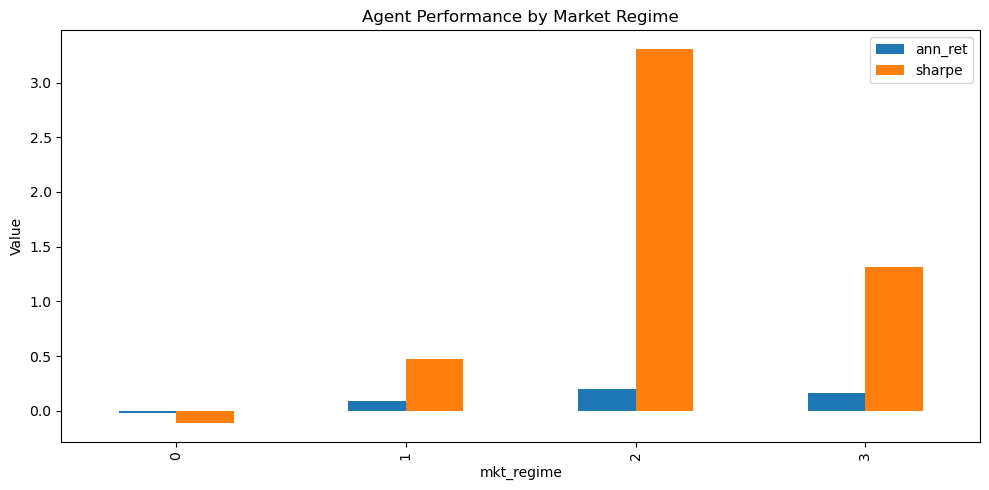

In [65]:
def perf_stats(x):
    ann_ret = np.mean(x) * 12
    ann_vol = np.std(x, ddof=1) * np.sqrt(12)
    sharpe = ann_ret / (ann_vol + 1e-12)
    return pd.Series({
        "ann_ret": ann_ret,
        "ann_vol": ann_vol,
        "sharpe": sharpe
    })

perf_by_regime = regime_perf_df.groupby("mkt_regime")["net_ret"].apply(perf_stats)
perf_plot = perf_by_regime.unstack()

perf_plot[["ann_ret", "sharpe"]].plot(kind="bar", figsize=(10,5))
plt.title("Agent Performance by Market Regime")
plt.ylabel("Value")
plt.tight_layout()
plt.show()



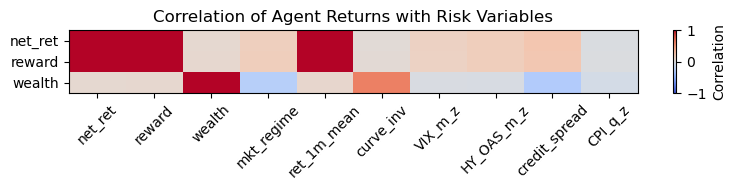

In [66]:
corr_matrix = regime_perf_df.corr()
corr_row = corr_matrix.loc[["net_ret", "reward", "wealth"]]

plt.figure(figsize=(8,2))
plt.imshow(corr_row.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_row.columns)), corr_row.columns, rotation=45)
plt.yticks([0,1,2], ["net_ret", "reward", "wealth"])

plt.title("Correlation of Agent Returns with Risk Variables")
plt.tight_layout()
plt.show()



### Policy based regime analysis

In [67]:

z_cols = [c for c in out.columns if c.startswith("z")]

Z = out[z_cols].values
Zs = StandardScaler().fit_transform(Z)

K_agent = 4
hmm_agent = GaussianHMM(n_components=K_agent, covariance_type="diag", n_iter=500, random_state=0)
hmm_agent.fit(Zs)

agent_regime = pd.Series(hmm_agent.predict(Zs), index=out.index, name="agent_regime")
agent_regime.value_counts()


agent_regime
1    53
0    27
2    26
3     2
Name: count, dtype: int64

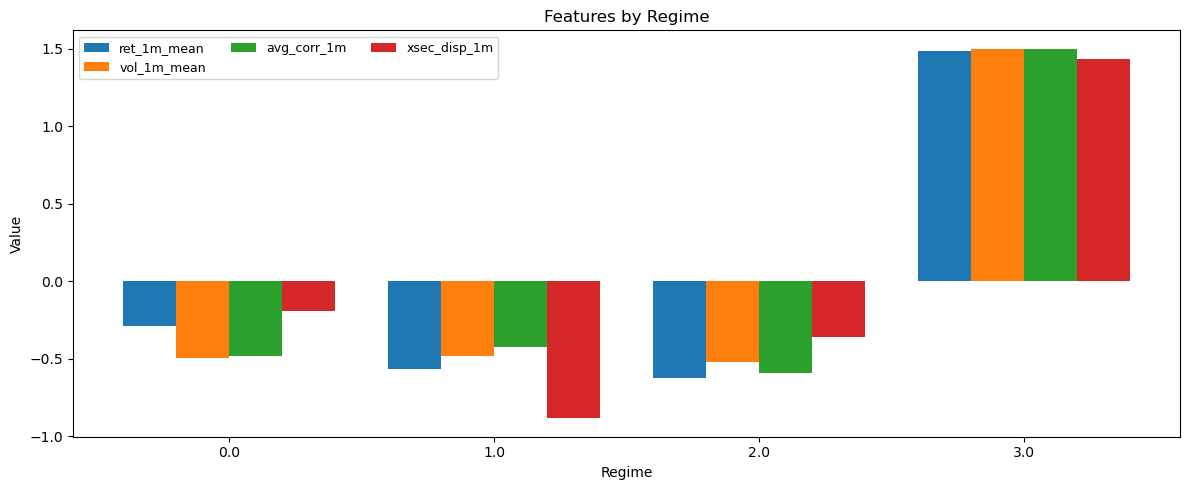

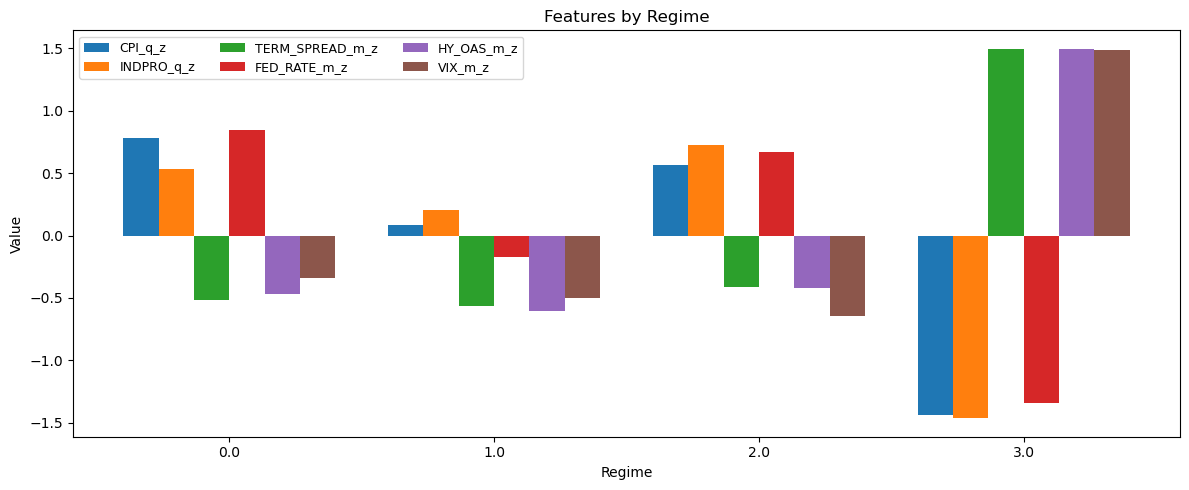

In [68]:
summary = df.join(agent_regime).groupby("agent_regime").mean()
summary




visuals = [
    ['ret_1m_mean', 'vol_1m_mean', 'avg_corr_1m', 'xsec_disp_1m'],
    ['CPI_q_z', 'INDPRO_q_z', 'TERM_SPREAD_m_z', 'FED_RATE_m_z', 'HY_OAS_m_z', 'VIX_m_z']
    
]
summary = (summary-summary.mean())/summary.std()
for cols in visuals:
    regimes = summary.index
    n_regimes = len(regimes)
    n_vars = len(cols)

    x = np.arange(n_regimes)

    # choose width based on how many bars you have
    width = 0.8 / n_vars   # total group width ~0.8

    plt.figure(figsize=(12,5))

    for i, col in enumerate(cols):
        plt.bar(x + i*width, summary[col].values, width=width, label=col)

    # center tick labels under the group
    plt.xticks(x + width*(n_vars-1)/2, regimes)

    plt.xlabel("Regime")
    plt.ylabel("Value")
    plt.title("Features by Regime")
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


In [69]:
regime_cols = df[["ret_1m_mean","curve_inv","VIX_m_z","HY_OAS_m_z","credit_spread","CPI_q_z"]]
out_regime = out[['net_ret', 'reward', 'wealth']]
agent_regime_perf_df = out.join(agent_regime, how="left")
agent_regime_perf_df = agent_regime_perf_df.join(regime_cols, how="left")
cols = ['net_ret', 'reward', 'wealth',
        'agent_regime', 'ret_1m_mean', 'curve_inv', 'VIX_m_z',
       'HY_OAS_m_z', 'credit_spread', 'CPI_q_z']
agent_regime_perf_df = agent_regime_perf_df[cols]
agent_regime_perf_df.head()

,net_ret,reward,wealth,agent_regime,ret_1m_mean,curve_inv,VIX_m_z,HY_OAS_m_z,credit_spread,CPI_q_z
date,,,,,,,,,,
2017-01-31,0.017108,0.016953,1.017108,0,0.013975,0,-0.124984,0.016223,0,0.993252
2017-02-28,0.029621,0.029162,1.047235,2,0.026933,0,-0.655788,-1.582065,0,1.078891
2017-03-31,-0.000661,-0.000670,1.046544,0,-0.003701,0,0.146048,-0.950084,0,0.206501
2017-04-30,0.010535,0.010474,1.057571,0,0.008050,0,-0.103543,0.064685,0,-0.542625
2017-05-31,0.010144,0.010077,1.068298,2,0.006076,0,-0.770055,0.709060,0,-1.112679


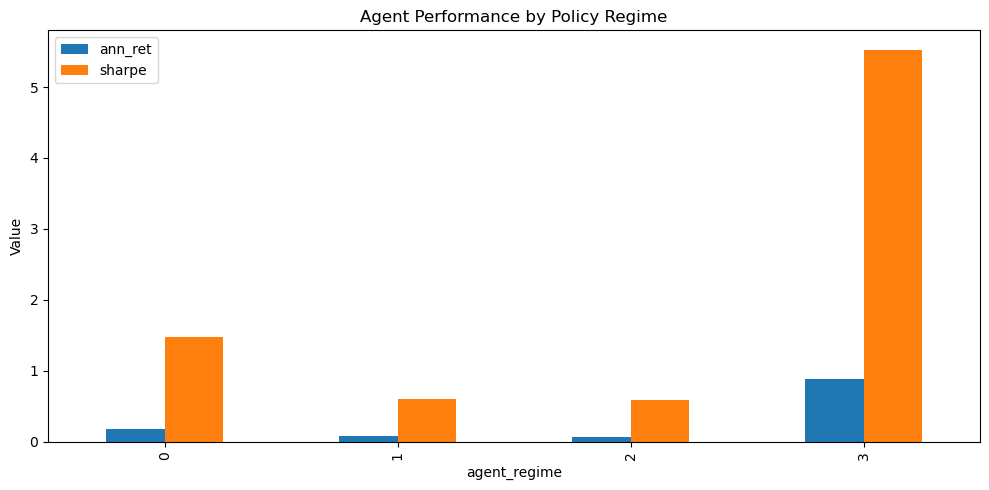

In [70]:
perf_by_agent_regime = agent_regime_perf_df.groupby("agent_regime")["net_ret"].apply(perf_stats)
perf_plot = perf_by_agent_regime.unstack()

perf_plot[["ann_ret", "sharpe"]].plot(kind="bar", figsize=(10,5))
plt.title("Agent Performance by Policy Regime")
plt.ylabel("Value")
plt.tight_layout()
plt.show()
